In [1]:
import sys
sys.path.append('../../src')

In [2]:
import pyarrow.compute as pc
from tls_profiling.io.readers import open_parquet_dataset

dataset = open_parquet_dataset(f"../../datasets/malware.parquet")
print("Loading dataset...")
df_malware_app_train = dataset.to_table(filter=( (pc.field("meta.sample.id") >= "250901-") & (pc.field("meta.sample.id") < "250921-" ))).to_pandas()
print(f"df_malware_app_train={len(df_malware_app_train)}")
df_malware_app_val = dataset.to_table(filter=( (pc.field("meta.sample.id") >= "250921-") & (pc.field("meta.sample.id") < "250926-" ))).to_pandas()
print(f"df_malware_app_val={len(df_malware_app_val)}")
df_malware_app_test = dataset.to_table(filter=( (pc.field("meta.sample.id") >= "250926-") & (pc.field("meta.sample.id") < "250931-" ))).to_pandas()
print(f"df_malware_app_test={len(df_malware_app_test)}")

Loading dataset...
df_malware_app_train=1059526
df_malware_app_val=147675
df_malware_app_test=197864


In [3]:
from tls_profiling.exploration.connections import get_connection_label
df_malware_app_train["connection_label"] = get_connection_label(df_malware_app_train)
df_malware_app_val["connection_label"] = get_connection_label(df_malware_app_val)
df_malware_app_test["connection_label"] = get_connection_label(df_malware_app_test)

In [4]:
from tls_profiling.baselines.model_isolation_forest import IsolationForestDetector, Config
from typing import Any, Iterable, Dict
import numpy as np
import pandas as pd


detector=IsolationForestDetector(Config())

def detection_pipeline(
    df_train: np.ndarray,
    df_val: np.ndarray,
    df_test: np.ndarray,
    target_fpr: float,
) -> Dict[str, Any]:


    # --- calibration on benign validation ---
    val_scores = detector.score(df_val)
    threshold = float(np.quantile(val_scores, 1.0 - target_fpr))

    # --- evaluation ---
    test_scores = detector.score(df_test)
    test_pred = (test_scores >= threshold)

    return {
        "target_fpr": target_fpr,
        "threshold": threshold,
        "val_fpr": float(np.mean(val_scores >= threshold)),
        "test_anom_rate": float(np.mean(test_pred)),
        "test_scores": test_scores,   # optional, can be dropped
    }

def run_fpr_sweep(
    df_train: np.ndarray,
    df_val: np.ndarray,
    df_test: np.ndarray,
    fpr_list: Iterable[float],
) -> pd.DataFrame:
    """
    Run the pipeline for multiple FPR targets and
    return a compact summary table.
    """
    rows = []

    for fpr in fpr_list:
        print(f"  Evaluating for FPR={fpr}")
        res = detection_pipeline(
            df_train=df_train,
            df_val=df_val,
            df_test=df_test,
            target_fpr=fpr,
        )

        rows.append({
            "target_fpr": res["target_fpr"],
            "threshold": res["threshold"],
            "val_fpr_realized": res["val_fpr"],
            "test_anom_rate": res["test_anom_rate"],
        })

    return pd.DataFrame(rows).sort_values("target_fpr")

Extracting features from source data.


/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['000A', '000F', '0029', '002A', '4469', 'FE0D'] will be ignored
  warnings.warn(
/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['0007', '0009', '000C', '000D', '000F', '0010', '0012', '0013', '0015', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '008A', '008C', '008D', '0090', '0091', '0094', '0095', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '00A8', '00A9', '00AA', '00AB', '00AC', '00AD', '00AE', '00AF', '00B2', '00B3', '00B6', '00B7', '00BA', '00BD', '00BE', '00C0', '00C3', '00C4', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AA

 Train data done.


/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['000A', '000F', '0029', '002A', '3A3A', '7550'] will be ignored
  warnings.warn(
/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['0003', '0006', '0007', '0008', '0009', '0011', '0012', '0013', '0014', '0015', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '00FB', '00FC', '00FD', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C002', 'C003', 'C004', 'C005', 'C008', 'C00C', 'C00D', 'C00E', 'C00F', 'C012', 'C019', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'C0

 Validation data done.


/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['000A', '000F', '0029', '002A'] will be ignored
  warnings.warn(
/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['0007', '000D', '0010', '0013', '0016', '0030', '0031', '0036', '0037', '003E', '003F', '0040', '0041', '0042', '0043', '0044', '0045', '0067', '0068', '0069', '006A', '006B', '0084', '0085', '0086', '0087', '0088', '0096', '0097', '0098', '0099', '009A', '00A0', '00A1', '00A2', '00A3', '00A4', '00A5', '00FB', '00FC', '00FD', '0A0A', '1A1A', '2A2A', '3A3A', '4A4A', '5A5A', '6A6A', '7A7A', '8A8A', '9A9A', 'AAAA', 'BABA', 'C002', 'C003', 'C004', 'C005', 'C008', 'C00C', 'C00D', 'C00E', 'C00F', 'C012', 'C019', 'C025', 'C026', 'C029', 'C02A', 'C02D', 'C02E', 'C031', 'C032', 'C07A', 'C07B', 'C07C', 'C07D', 'C086', 'C087', 'C08A', 'C08B', 'C0

 Test data done.
Fitting preprocessor.
Preprocessor created, running FPR sweep:
  Evaluating for FPR=0.0001
  Evaluating for FPR=0.0002
  Evaluating for FPR=0.0005
  Evaluating for FPR=0.001
  Evaluating for FPR=0.005
  Evaluating for FPR=0.002
  Evaluating for FPR=0.01
  Evaluating for FPR=0.02
  Evaluating for FPR=0.05


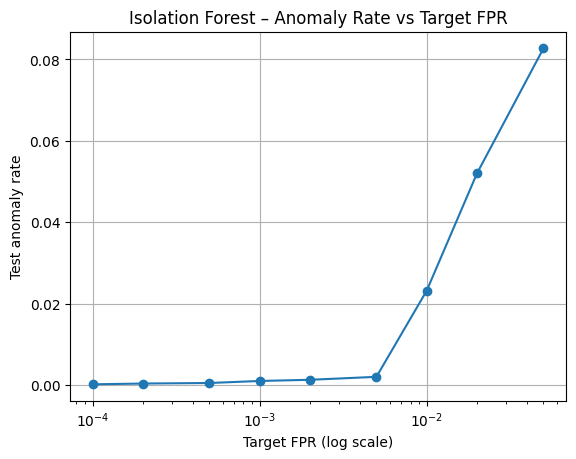

In [5]:
fpr_values = [
    1e-4,
    2e-4,
    5e-4,
    1e-3,
    5e-3,
    2e-3,
    1e-2,
    2e-2,
    5e-2,
]

from tls_profiling.preprocessing import extract_features, build_and_fit_preprocessor

print("Extracting features from source data.")
# transform loaded datasets to feature input for models:
df_malware_train = extract_features(df_malware_app_train)
print(" Train data done.")
df_malware_val = extract_features(df_malware_app_val)
print(" Validation data done.")
df_malware_test = extract_features(df_malware_app_test)
print(" Test data done.")

print("Fitting preprocessor.")
# fit preprocessors that learns the categorical features encoding
preprocessor=build_and_fit_preprocessor(df_malware_train)

detector.fit(preprocessor.transform(df_malware_train))

print("Preprocessor created, running FPR sweep:")
df_results = run_fpr_sweep(
    df_train=preprocessor.transform(df_malware_train),
    df_val=preprocessor.transform(df_malware_val),
    df_test=preprocessor.transform(df_malware_test),
    fpr_list=fpr_values,
)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    df_results["target_fpr"],
    df_results["test_anom_rate"],
    marker="o",
)
plt.xscale("log")
plt.xlabel("Target FPR (log scale)")
plt.ylabel("Test anomaly rate")
plt.title("Isolation Forest – Anomaly Rate vs Target FPR")
plt.grid(True)
plt.show()